In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

plt.figure(figsize=(10,6))
sns.set_style("whitegrid")

<Figure size 1000x600 with 0 Axes>

In [3]:
df = pd.read_csv(r"C:\Users\User\Downloads\data_projects\archive (11)\USvideos.csv", encoding='utf-8')

In [4]:
df.head()

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,2kyS6SvSYSE,17.14.11,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13T17:13:01.000Z,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...
1,1ZAPwfrtAFY,17.14.11,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13T07:30:00.000Z,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John..."
2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12T19:05:24.000Z,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► http...
3,puqaWrEC7tY,17.14.11,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,2017-11-13T11:00:04.000Z,"rhett and link|""gmm""|""good mythical morning""|""...",343168,10172,666,2146,https://i.ytimg.com/vi/puqaWrEC7tY/default.jpg,False,False,False,Today we find out if Link is a Nickelback amat...
4,d380meD0W0M,17.14.11,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12T18:01:41.000Z,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095731,132235,1989,17518,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...


In [6]:
print(df.shape)

(40949, 16)


In [7]:
print(df.columns)

Index(['video_id', 'trending_date', 'title', 'channel_title', 'category_id',
       'publish_time', 'tags', 'views', 'likes', 'dislikes', 'comment_count',
       'thumbnail_link', 'comments_disabled', 'ratings_disabled',
       'video_error_or_removed', 'description'],
      dtype='str')


In [9]:
with open(r"C:\Users\User\Downloads\data_projects\archive (11)\US_category_id.json") as f:
    categories = json.load(f)

In [10]:
category_map = {}
for item in categories['items']:category_map[int(item['id'])] = item['snippet']['title']
category_map

{1: 'Film & Animation',
 2: 'Autos & Vehicles',
 10: 'Music',
 15: 'Pets & Animals',
 17: 'Sports',
 18: 'Short Movies',
 19: 'Travel & Events',
 20: 'Gaming',
 21: 'Videoblogging',
 22: 'People & Blogs',
 23: 'Comedy',
 24: 'Entertainment',
 25: 'News & Politics',
 26: 'Howto & Style',
 27: 'Education',
 28: 'Science & Technology',
 29: 'Nonprofits & Activism',
 30: 'Movies',
 31: 'Anime/Animation',
 32: 'Action/Adventure',
 33: 'Classics',
 34: 'Comedy',
 35: 'Documentary',
 36: 'Drama',
 37: 'Family',
 38: 'Foreign',
 39: 'Horror',
 40: 'Sci-Fi/Fantasy',
 41: 'Thriller',
 42: 'Shorts',
 43: 'Shows',
 44: 'Trailers'}

In [11]:
df['category_name'] = df['category_id'].map(category_map)
df[['category_id', 'category_name']].head()

,category_id,category_name
0,22,People & Blogs
1,24,Entertainment
2,23,Comedy
3,24,Entertainment
4,24,Entertainment


In [12]:
df['trending_date'] = pd.to_datetime(df['trending_date'],format='%y.%d.%m')
df['publish_time'] = pd.to_datetime(df['publish_time'])

In [13]:
df['engagement_rate'] = ((df['likes'] + df['dislikes'] + df['comment_count'])/ df['views']) * 100
df['like_rate'] = (df['likes'] / df['views']) * 100
df['dislike_rate'] = (df['dislikes'] / df['views']) * 100

In [15]:
df['publish_time'] = pd.to_datetime(df['publish_time']).dt.tz_localize(None)

In [16]:
df['days_to_trend'] = (df['trending_date'] - df['publish_time']).dt.days

In [17]:
df = df.sort_values('trending_date')
df = df.drop_duplicates(subset='video_id',keep='first')
df.shape

(6351, 21)

In [18]:
df.describe()

,trending_date,category_id,publish_time,views,likes,dislikes,comment_count,engagement_rate,like_rate,dislike_rate,days_to_trend
count,6351,6351.000000,6351,6.351000e+03,6.351000e+03,6351.000000,6351.000000,6351.000000,6351.000000,6351.000000,6351.000000
mean,2018-02-03 08:09:31.374586,20.444182,2018-01-12 09:31:03.443080,7.582098e+05,3.449357e+04,1427.222012,4501.707290,4.764768,4.028288,0.172006,21.521650
min,2017-11-14 00:00:00,1.000000,2006-07-23 08:24:11,5.490000e+02,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000
25%,2017-12-15 00:00:00,17.000000,2017-12-13 04:38:24,8.351100e+04,1.908000e+03,72.000000,261.000000,1.924750,1.439044,0.051818,0.000000
50%,2018-01-27 00:00:00,24.000000,2018-01-25 02:00:01,2.709020e+05,7.987000e+03,242.000000,921.000000,3.802762,3.141512,0.091269,1.000000
75%,2018-03-15 00:00:00,25.000000,2018-03-13 09:32:25,7.512665e+05,2.516300e+04,763.000000,2845.000000,6.405392,5.536296,0.166489,2.000000
max,2018-06-14 00:00:00,43.000000,2018-06-14 01:31:53,4.843165e+07,3.880071e+06,629120.000000,733373.000000,33.025531,29.046646,19.153148,4214.000000
std,NaN,7.213046,NaN,1.928993e+06,1.162439e+05,12078.814524,21460.223331,3.898611,3.490346,0.444790,209.963237


In [19]:
corr_columns = ['views','likes','dislikes','comment_count','engagement_rate','days_to_trend']
correlation_matrix = df[corr_columns].corr(method='pearson')
correlation_matrix

,views,likes,dislikes,comment_count,engagement_rate,days_to_trend
views,1.000000,0.761127,0.396135,0.599628,0.057128,-0.035336
likes,0.761127,1.000000,0.360274,0.806198,0.318552,-0.028872
dislikes,0.396135,0.360274,1.000000,0.679838,0.097088,-0.011298
comment_count,0.599628,0.806198,0.679838,1.000000,0.258414,-0.020393
engagement_rate,0.057128,0.318552,0.097088,0.258414,1.000000,-0.103773
days_to_trend,-0.035336,-0.028872,-0.011298,-0.020393,-0.103773,1.000000


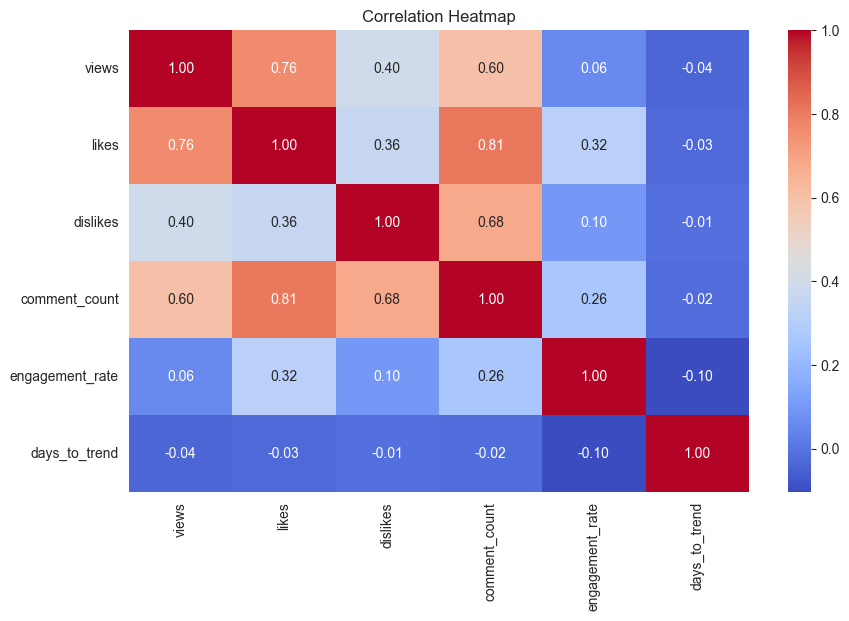

In [21]:
plt.figure(figsize=(10,6))
sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm',fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

In [22]:
print(correlation_matrix[['views']].sort_values(by='views',ascending=False))

                    views
views            1.000000
likes            0.761127
comment_count    0.599628
dislikes         0.396135
engagement_rate  0.057128
days_to_trend   -0.035336


In [23]:
category_analysis = df.groupby('category_name'
).agg({
    'views':'mean',
    'engagement_rate':'mean',
    'like_rate':'mean'
}).sort_values(
    by='views',
    ascending=False)
category_analysis.head(10)

,views,engagement_rate,like_rate
category_name,,,
Music,1.387621e+06,8.234088,7.401756
Gaming,1.211844e+06,5.482981,4.380282
Nonprofits & Activism,1.025217e+06,4.830642,3.744533
Film & Animation,9.204330e+05,4.029484,3.397430
Sports,8.302815e+05,2.039082,1.611957
Entertainment,8.171242e+05,3.843338,3.204845
Comedy,7.729546e+05,5.689227,4.971189
People & Blogs,7.127675e+05,5.505346,4.700354
Science & Technology,5.843225e+05,4.231290,3.580616


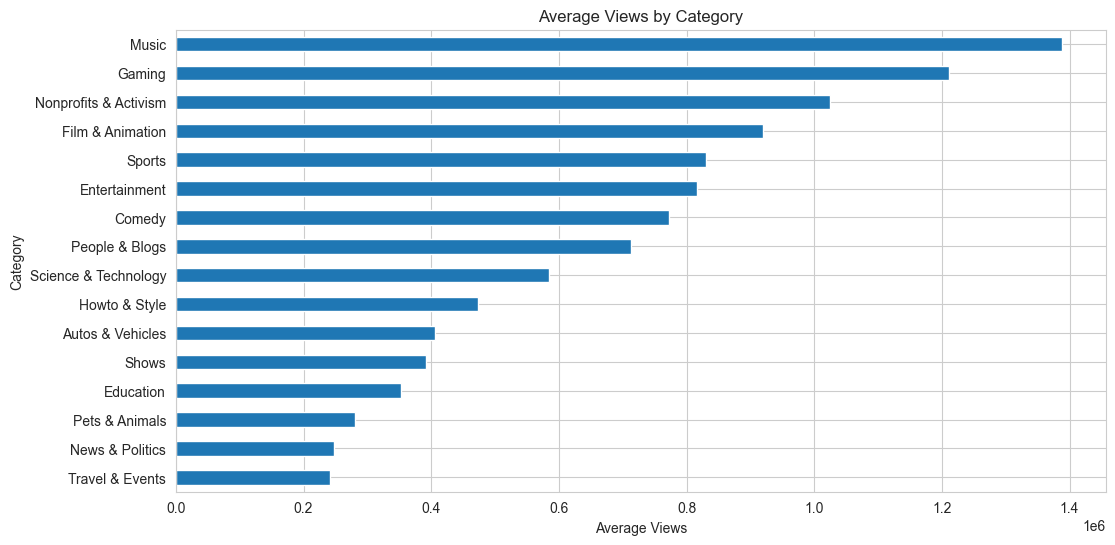

In [27]:
plt.figure(figsize=(12,6))
category_analysis['views'].sort_values().plot(
    kind='barh')
plt.title("Average Views by Category")
plt.xlabel("Average Views")
plt.ylabel("Category")
plt.show()

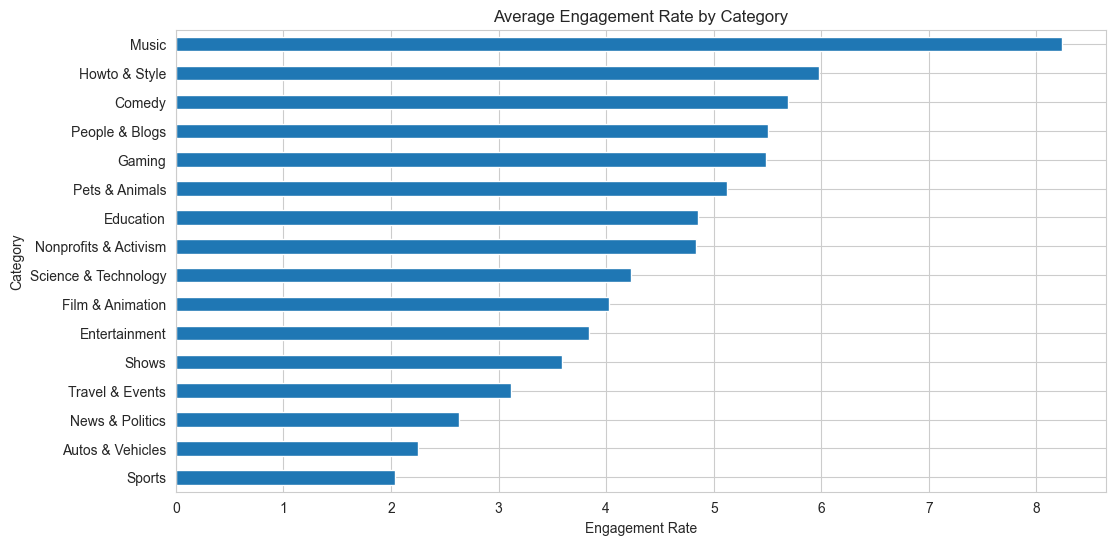

In [29]:
plt.figure(figsize=(12,6))
category_analysis[
    'engagement_rate'
].sort_values().plot(
    kind='barh')
plt.title("Average Engagement Rate by Category")
plt.xlabel("Engagement Rate")
plt.ylabel("Category")
plt.show()

In [30]:
df['publish_day'] = df['publish_time'].dt.day_name()

In [33]:
weekday_views = df.groupby('publish_day'
)['views'].mean().sort_values(
    ascending=False)
weekday_views # hansi gun daha cox views getirir

publish_day
Friday       894334.042025
Sunday       859492.576029
Monday       750340.857868
Saturday     726031.160878
Tuesday      722556.557022
Thursday     713014.400000
Wednesday    677738.515953
Name: views, dtype: float64

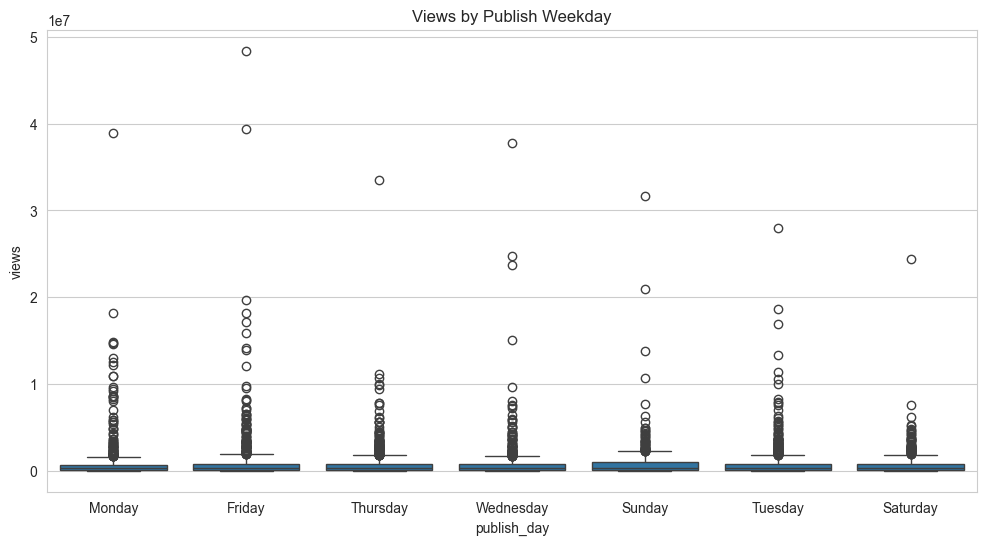

In [35]:
plt.figure(figsize=(12,6))
sns.boxplot(
    x='publish_day',
    y='views',
    data=df)
plt.xticks(rotation=0)
plt.title("Views by Publish Weekday")
plt.show()

In [36]:
top_videos = df.sort_values(by='views',
    ascending=False
)[[
    'title',
    'category_name',
    'views',
    'engagement_rate',
    'days_to_trend'
]].head(10)
top_videos

,title,category_name,views,engagement_rate,days_to_trend
23824,Maluma - El Préstamo (Official Video),Music,48431654,1.425787,5
35550,BTS (방탄소년단) 'FAKE LOVE' Official MV,Music,39349927,11.804553,0
28605,TWICE What is Love? M/V,Music,38873543,3.639059,4
3200,Marvel Studios' Avengers: Infinity War Officia...,Entertainment,37736281,5.297557,0
70,Ed Sheeran - Perfect (Official Music Video),Music,33523622,5.191184,4
33351,Childish Gambino - This Is America (Official V...,Music,31648454,5.075682,1
30750,VENOM - Official Trailer (HD),Entertainment,27973210,3.480723,0
4600,YouTube Rewind: The Shape of 2017 | #YouTubeRe...,Entertainment,24782158,8.454518,0
28624,Drake - Nice For What,Music,24421448,2.870477,6
38161,Sanju | Official Trailer | Ranbir Kapoor | Raj...,Entertainment,23758250,2.735273,1


In [37]:
high_views_low_engagement = df[
    (df['views'] > df['views'].quantile(0.90)) &
    (df['engagement_rate'] < df['engagement_rate'].median())]
low_views_high_engagement = df[
    (df['views'] < df['views'].median()) &
    (df['engagement_rate'] > df['engagement_rate'].quantile(0.90))]

In [38]:
print("High views but low engagement:",
    len(high_views_low_engagement))
print("Low views but high engagement:",
    len(low_views_high_engagement))

High views but low engagement: 276
Low views but high engagement: 281


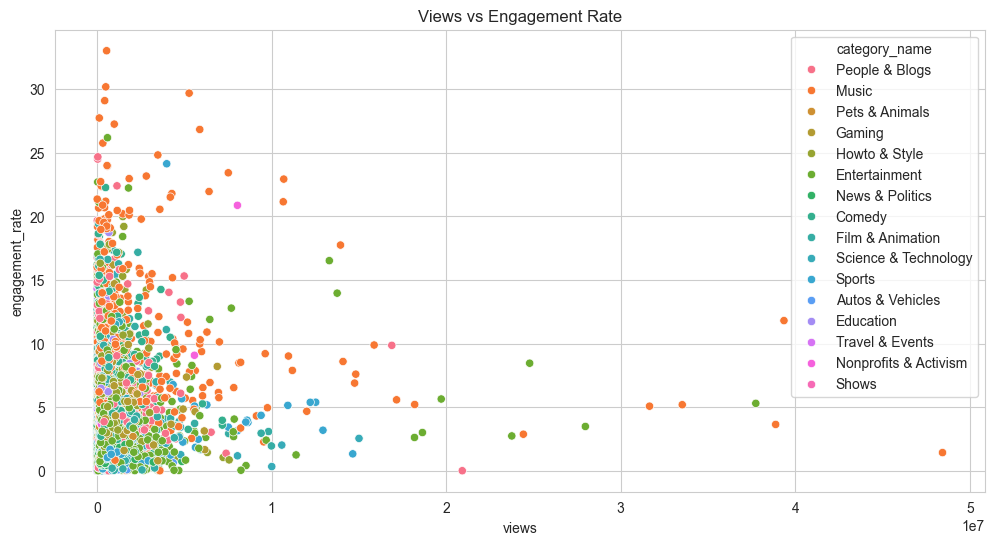

In [40]:
plt.figure(figsize=(12,6))
sns.scatterplot(
    data=df,
    x='views',
    y='engagement_rate',
    hue='category_name')
plt.title("Views vs Engagement Rate")
plt.show()